# Spatial · single-field — pipeline demo template

The **spatial single-field** template.  Every demo in this group follows the same three steps — **load → run → plot** — all driven by [`daedalus.py`](../daedalus.py):

1. **Load** a theory from `theories/<name>.theory.py` (the single source of truth — no inline model building).
2. **Run** it with one `dd.Config(...)`: the correlator order `k`, the loop order `max_ell`, the Dyson order, the grids, and every plotting option live there.
3. **Plot** with `dd.plot_cumulant`, which auto-dispatches to the form natural to this group.

This template ships with **`kpz_1d`**.  To demo a different spatial theory, set `THEORY` below to any single-field spatial `theories/*.theory.py` (e.g. `allen_cahn_1d_subcritical_infinite`, `burgers_1d`, `reaction_diffusion_quadratic_1d`).  Everything else is identical across all four group templates on purpose — common thematics for the demos.

## 1. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
import daedalus as dd
print('daedalus \u2192', dd.REPO_ROOT)

daedalus → /Users/matthewszuromi/Documents/Education/BU PhD/Ocker Lab/Automated Feynman Calculations


## 2. Choose the theory & configure the run

This is the only cell you edit.  `k` and `max_ell` are free (arbitrary correlator order and loop order); the plotting options (`show_orders`, `logy`, `figsize`, …) are adaptable.

In [2]:
THEORY = 'kpz_1d'   # any single-field spatial theory

cfg = dd.Config(
    k=2,
    max_ell=1,      # 0 = tree, 1 = +1-loop, …
    # output='cumulant', # 'cumulant' (default) | 'moment' | 'central_moment' (k=2)

    # --- spatial grid: (lo, hi, n_points) or an explicit array ---
    spatial_grid=(-6.0, 6.0, 49),
    tau_max=0.0,    # > 0 adds a C(x, τ) heatmap panel
    tau_step=1.0,

    show_orders='cumulative',
    logy=False,
    # For k ≥ 3 set spatial_points=(n_pts, k-1, 2) of (x_j, τ_j)
    # offsets instead of spatial_grid (see the k≥3 note below).
)

In [3]:
model, mod = dd.load_theory(THEORY)
print('loaded :', model.get('name'))
print('fields :', dd.field_names(model),
      '| spatial_dim:', dd.spatial_dim(model),
      '| multi-field:', dd.is_multifield(model))
print('params :', [p['name'] for p in (model.get('parameters') or [])])

loaded : 1D KPZ (per-leg gradient vertex)
fields : ['dh'] | spatial_dim: 1 | multi-field: False
params : ['hstar', 'mu', 'D', 'lam', 'T']


## 3. Run

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))

theory : '1D KPZ (per-leg gradient vertex)'
k      : 2    max_ell : 1
fields : ['dh']   spatial_dim : 1
diagrams (live): 3


## 4. Plot

`show_orders` controls the per-loop-order overlay: `'cumulative'` (tree, tree+1-loop, …), `'incremental'` (each order alone), or `'total'` (the summed result only).

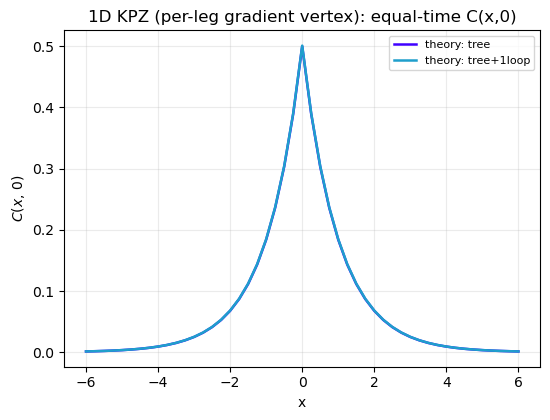

In [5]:
fig = dd.plot_cumulant(res, cfg, model)
plt.show()

### Arbitrary `k` (spatial)

For 3-point and higher spatial cumulants, replace `spatial_grid` with explicit evaluation events: `spatial_points` is an `(n_pts, k-1, 2)` array giving, for each of the `k-1` non-anchor legs, its `(x_j, τ_j)` offset from the anchor.  `dd.plot_cumulant` then draws the per-event bar chart automatically.  Example (`k=3`, two events):

```python
cfg = dd.Config(k=3, max_ell=0, spatial_points=[
    [[0.5, 0.0], [1.0, 0.0]],   # event 1: legs at x=0.5 and x=1.0
    [[1.0, 0.0], [2.0, 0.0]],   # event 2
])
```